#  Phishing Email Detector —> Full ML Pipeline

**Dataset:** `phishing_dataset.csv` ~ 70,486 emails, 11 features, binary label (1 = phishing, 0 = legitimate)

### Pipeline Overview
1. EDA & data validation
2. Feature engineering (text + structural)
3. Preprocessing pipeline (TF-IDF + numeric)
4. Model training (Random Forest + Logistic Regression ensemble)
5. Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix)
6. Model export for Flask deployment


In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('All imports OK ✅')
print(f'scikit-learn version: {__import__("sklearn").__version__}')

All imports OK ✅
scikit-learn version: 1.8.0


## 1\ Loading & Validating the Dataset:

In [2]:
#  adjusting path if running from a different directory 
DATA_PATH = 'final_dataset2.csv'  

# Keeping an untouched copy for leakage-safe train/test split
raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()  # Used for EDA / inspection cells

print(f'Shape: {df.shape}')
df.head(3)

Shape: (70986, 11)


,subject,from_email,to_email,body_clean,urls,url_count,char_count,word_count,has_ip_url,html_flag,label
0,make your intimate life more pleasant,lorant ryan <marrandino@theborgata.com>,user2.6@gvc.ceas-challenge.cc,Dear 1b10055440efac18fc80423f8be268d5 Summer i...,[],0,306,54,0,0,1
1,get great prices on medications,NaN,NaN,discount generic drugs . save over 70 % todays...,[],0,347,87,0,0,1
2,CNN.com Daily Top 10,Daily Top 10 <lufssewo@wilgrist.com>,email924@gvc.ceas-challenge.cc,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,['http://www.cnn.com/video/partners/email/inde...,24,3650,293,0,0,1


In [3]:
print('=== Column Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Label Distribution ===')
vc = df['label'].value_counts()
print(vc)
balance = vc[1] / len(df) * 100
print(f"\nPhishing rate: {balance:.1f}%  ← {'balanced' if 40 < balance < 60 else 'imbalanced'}")

=== Column Info ===
subject       object
from_email    object
to_email      object
body_clean    object
urls          object
url_count      int64
char_count     int64
word_count     int64
has_ip_url     int64
html_flag      int64
label          int64
dtype: object

=== Missing Values ===
subject         230
from_email    29767
to_email      30325
body_clean        2
urls            166
url_count         0
char_count        0
word_count        0
has_ip_url        0
html_flag         0
label             0
dtype: int64

=== Label Distribution ===
label
1    37383
0    33603
Name: count, dtype: int64

Phishing rate: 52.7%  ← balanced


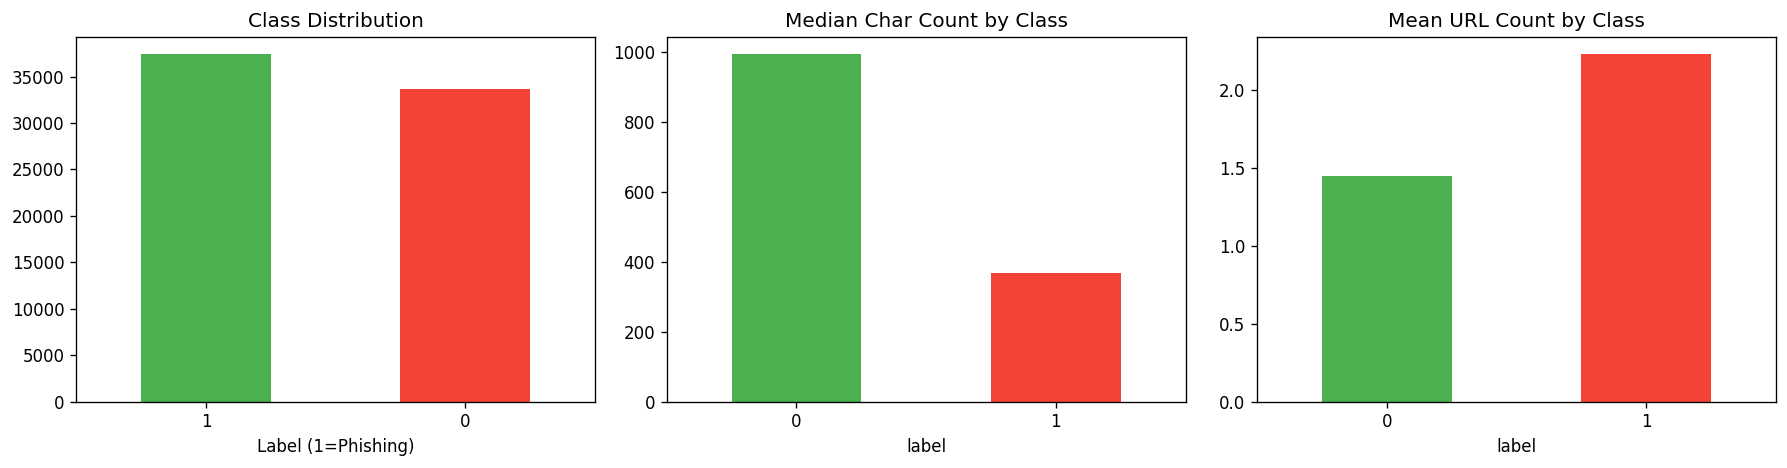

EDA plots saved


In [4]:
# EDA plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4CAF50','#F44336'], rot=0)
axes[0].set_title('Class Distribution'); axes[0].set_xlabel('Label (1=Phishing)')

df.groupby('label')['char_count'].median().plot(kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], rot=0)
axes[1].set_title('Median Char Count by Class')

df.groupby('label')['url_count'].mean().plot(kind='bar', ax=axes[2], color=['#4CAF50','#F44336'], rot=0)
axes[2].set_title('Mean URL Count by Class')

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print('EDA plots saved')

## 2\ Feature Engineering:

In [5]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add handcrafted features on top of raw dataset columns."""
    from urllib.parse import urlparse

    df = df.copy()

    # ── Fill missing text fields ──
    for col in ['subject', 'body_clean', 'from_email', 'to_email', 'urls']:
        if col in df.columns:
            df[col] = df[col].fillna('')
        else:
            df[col] = ''

    def extract_email_domain(email) -> str:
        """Safely extract a normalized domain from an email-like string."""
        if not isinstance(email, str):
            return ''

        email = email.strip().lower()
        if not email or '@' not in email:
            return ''

        local_part, domain = email.rsplit('@', 1)
        domain = domain.strip().strip('.')

        if not local_part or not domain or ' ' in domain:
            return ''
        if not re.fullmatch(r'[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(?:\.[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)*', domain):
            return ''

        return domain

    def extract_url_domain(url) -> str:
        """Safely extract a normalized domain from a URL-like string."""
        if not isinstance(url, str):
            return ''

        url = url.strip().lower()
        if not url:
            return ''

        # Accepting host/path-like URLs by prepending a scheme for parsing:
        if url.startswith('//'):
            url = 'https:' + url
        elif '://' not in url:
            url = 'https://' + url

        try:
            parsed = urlparse(url)
        except Exception:
            return ''

        host = (parsed.netloc or parsed.path.split('/')[0]).strip()
        host = host.split('@')[-1].split(':')[0].strip().strip('.')

        if not host or ' ' in host:
            return ''
        if not re.fullmatch(r'[a-z0-9](?:[a-z0-9-]*[a-z0-9])?(?:\.[a-z0-9](?:[a-z0-9-]*[a-z0-9])?)*', host):
            return ''

        return host

    df['from_domain'] = df['from_email'].apply(extract_email_domain)
    df['to_domain'] = df['to_email'].apply(extract_email_domain)
    df['same_domain'] = (
        (df['from_domain'] != '') & (df['from_domain'] == df['to_domain'])
    ).astype(int)
    df['is_edu_domain'] = df['from_domain'].str.contains(r'\.(edu|dz)(?:\.|$)', regex=True).fillna(False).astype(int)

    # URL-based domain features (vectorized with explode/groupby):
    split_urls = df['urls'].astype(str).str.split(r'\s*,\s*')
    exploded_urls = split_urls.explode()
    exploded_domains = exploded_urls.map(extract_url_domain)
    valid_domains = exploded_domains[exploded_domains != '']

    grouped_domains = valid_domains.groupby(level=0).agg(list)
    df['url_domains'] = df.index.to_series().map(grouped_domains)
    df['url_domains'] = df['url_domains'].apply(lambda v: v if isinstance(v, list) else [])

    edu_flags = valid_domains.str.contains(r'\.(edu|dz)(?:\.|$)', regex=True)
    any_edu = edu_flags.groupby(level=0).any()
    df['url_is_edu'] = df.index.to_series().map(any_edu).fillna(False).astype(int)

    mismatch_flags = (
        valid_domains != df.loc[valid_domains.index, 'from_domain']
    ).groupby(level=0).any()
    df['url_domain_mismatch'] = (
        (df['from_domain'] != '') & df.index.to_series().map(mismatch_flags).fillna(False)
    ).astype(int)

    # Combined text blob (subject + body) for TF-IDF 
    df['text_combined'] = df['subject'].str.lower() + ' ' + df['body_clean'].str.lower()

    # Structural / metadata features
    df['subject_len'] = df['subject'].str.len()
    df['subject_excl'] = df['subject'].str.count('!')
    df['subject_caps_ratio'] = df['subject'].apply(
        lambda s: sum(c.isupper() for c in s) / max(len(s), 1)
    )

    df['body_excl_count'] = df['body_clean'].str.count('!')
    df['body_dollar_count'] = df['body_clean'].str.count(r'\$')
    body_text = df['body_clean'].str.lower()
    urgent_token_hits = body_text.str.count(
        r'\b(urgent|verify|suspend|click|password|login|free|winner)\b'
    )
    credential_phrase_hits = body_text.str.count(
        r'\b(verify|update|secure|unlock)\s+(?:your\s+)?account\b'
        r'|\b(account|password)\s+(?:has|was)\s+(?:been\s+)?(?:suspended|locked|compromised)\b'
    )
    df['body_urgent_words'] = urgent_token_hits + credential_phrase_hits

    # IP based URL ratio
    df['ip_url_ratio'] = df['has_ip_url'] / df['url_count'].clip(lower=1)

    # Log transform skewed numerics
    df['log_char_count'] = np.log1p(df['char_count'])
    df['log_word_count'] = np.log1p(df['word_count'])
    df['log_url_count'] = np.log1p(df['url_count'])

    #  Displaying name vs sender domain mismatch :
    BRAND_DOMAINS = {
        'paypal':    ['paypal.com'],
        'amazon':    ['amazon.com', 'amazon.co.uk', 'amazonses.com'],
        'microsoft': ['microsoft.com', 'outlook.com', 'hotmail.com', 'live.com'],
        'google':    ['google.com', 'gmail.com'],
        'apple':     ['apple.com', 'icloud.com'],
        'netflix':   ['netflix.com'],
        'dhl':       ['dhl.com'],
        'fedex':     ['fedex.com'],
        'ups':       ['ups.com'],
    }

    def display_name_domain_mismatch(from_field: str, actual_domain: str) -> int:
        """Return 1 if display name claims a known brand but sending domain doesn't match."""
        if not isinstance(from_field, str) or not actual_domain:
            return 0
        name_part = from_field.lower()
        for brand, legit_domains in BRAND_DOMAINS.items():
            if brand in name_part:
                if not any(actual_domain == d or actual_domain.endswith('.' + d)
                           for d in legit_domains):
                    return 1
        return 0

    df['display_name_mismatch'] = df.apply(
        lambda r: display_name_domain_mismatch(r['from_email'], r['from_domain']), axis=1
    )

    # Lookalike / typosquatting domain detection :
    try:
        from Levenshtein import distance as lev_distance
        HAS_LEVENSHTEIN = True
    except ImportError:
        HAS_LEVENSHTEIN = False

    KNOWN_LEGIT_DOMAINS = [
        'paypal.com', 'amazon.com', 'microsoft.com', 'google.com',
        'apple.com', 'netflix.com', 'dhl.com', 'fedex.com', 'ups.com',
    ]

    def is_lookalike_domain(domain: str, threshold: int = 2) -> int:
        """Return 1 if domain is suspiciously close to a known brand but not exact."""
        if not domain or not HAS_LEVENSHTEIN:
            return 0
        parts = domain.split('.')
        if len(parts) < 2:
            return 0
        apex = '.'.join(parts[-2:])
        for legit in KNOWN_LEGIT_DOMAINS:
            if apex == legit:
                return 0  # exact match — legitimate
            if lev_distance(apex, legit) <= threshold:
                return 1  # close but not exact — suspicious
        return 0

    df['lookalike_domain'] = df['from_domain'].apply(is_lookalike_domain)

    # ── Reply-To vs From domain mismatch ──
    if 'reply_to' in df.columns:
        df['reply_to'] = df['reply_to'].fillna('')
        df['reply_to_domain'] = df['reply_to'].apply(extract_email_domain)
        df['replyto_mismatch'] = (
            (df['from_domain'] != '') &
            (df['reply_to_domain'] != '') &
            (df['from_domain'] != df['reply_to_domain'])
        ).astype(int)
    else:
        df['replyto_mismatch'] = 0

    return df


df = engineer_features(df)
print('Feature engineering done')
print('New columns:', [c for c in df.columns if c not in ['subject', 'from_email', 'to_email', 'body_clean', 'urls', 'label']])

Feature engineering done
New columns: ['url_count', 'char_count', 'word_count', 'has_ip_url', 'html_flag', 'from_domain', 'to_domain', 'same_domain', 'is_edu_domain', 'url_domains', 'url_is_edu', 'url_domain_mismatch', 'text_combined', 'subject_len', 'subject_excl', 'subject_caps_ratio', 'body_excl_count', 'body_dollar_count', 'body_urgent_words', 'ip_url_ratio', 'log_char_count', 'log_word_count', 'log_url_count', 'display_name_mismatch', 'lookalike_domain', 'replyto_mismatch']


## 3\Custom Transformers & Pipeline:

In [6]:
# Local imports make this cell runnable even if previous import cells were skipped:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Keeping numeric columns centralized so train/test and export metadata stay aligned
NUMERIC_FEATURES = [
    'url_count', 'has_ip_url', 'html_flag',
    'subject_len', 'subject_excl', 'subject_caps_ratio',
    'body_excl_count', 'body_dollar_count', 'body_urgent_words',
    'ip_url_ratio', 'log_char_count', 'log_word_count', 'log_url_count',
    'same_domain', 'is_edu_domain', 'url_is_edu', 'url_domain_mismatch',
    'display_name_mismatch', 'lookalike_domain', 'replyto_mismatch'
]

# Numeric branch: impute + scale on training folds only (prevents leakage)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combined preprocessing: TF-IDF text + numeric features in one transformer
features = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            max_features=5000,   # Cap vocabulary size to reduce overfitting and memory use
            ngram_range=(1, 1),   # Unigrams only (bigrams add cost without clear gain here)
            sublinear_tf=True,    # Use log-scaled term frequency to damp repeated keywords
            min_df=3,             # Ignore very rare terms that are often noisy
            max_df=0.85,          # Drop near-universal terms that add little discriminative signal
            stop_words='english', # Remove common English stopwords to reduce spurious correlations
            analyzer='word',
            strip_accents='unicode'
        ), 'text_combined'),
        ('numeric', numeric_pipeline, NUMERIC_FEATURES),
    ],
    remainder='drop'
 )

print('Pipeline architecture defined')

Pipeline architecture defined


## 4\ Train / Test Split:

In [7]:
# 1) Splitting ORIGINAL dataset first (stratified, untouched):
base_df = raw_df.copy() if 'raw_df' in globals() else pd.read_csv(DATA_PATH)

X_raw = base_df.drop(columns=['label'])
y = base_df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

# 2) Adding generated university emails ONLY to TRAIN set:
generated_df = globals().get('generated_university_df', None)
if generated_df is not None and len(generated_df) > 0:
    gen_df = generated_df.copy()

    # Ensuring generated rows have labels; default to legitimate if label is absent:
    if 'label' not in gen_df.columns:
        gen_df['label'] = 0

    X_gen = gen_df.drop(columns=['label'])
    y_gen = gen_df['label']

    X_train_raw = pd.concat([X_train_raw, X_gen], ignore_index=True)
    y_train = pd.concat([y_train.reset_index(drop=True), y_gen.reset_index(drop=True)], ignore_index=True)

# Feature engineering is handled inside the pipeline (FunctionTransformer):
# Passing raw splits directly to model_pipeline — do NOT pre-engineer here:
print(f'Train: {X_train_raw.shape[0]:,} samples | Test: {X_test_raw.shape[0]:,} samples')
print(f'Train phishing rate: {y_train.mean()*100:.1f}%')
print(f'Test  phishing rate: {y_test.mean()*100:.1f}%')

Train: 56,788 samples | Test: 14,198 samples
Train phishing rate: 52.7%
Test  phishing rate: 52.7%


## 5\ Model Training : Soft Voting Ensemble

In [8]:
# Enabling FAST_MODE during experimentation to reduce training time
# Setting FAST_MODE=False for final model training/export:
FAST_MODE = True

# Define base classifiers 
if FAST_MODE:
    rf = RandomForestClassifier(
        n_estimators=120, max_depth=16, min_samples_leaf=2,
        n_jobs=1, random_state=42
    )
    lr = LogisticRegression(C=1.0, max_iter=600, solver='saga', random_state=42)

    # Using a lighter 2-model ensemble for quick iteration:
    ensemble = VotingClassifier(
        estimators=[('rf', rf), ('lr', lr)],
        voting='soft',
        weights=[3, 1]
    )
else:
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=2,
        n_jobs=1, random_state=42
    )
    lr = LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42)
    gb = GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42
    )

    # Full ensemble for best final quality
    ensemble = VotingClassifier(
        estimators=[('rf', rf), ('lr', lr), ('gb', gb)],
        voting='soft',
        weights=[3, 1, 2]
    )

# Full deployment pipeline: feature engineering + preprocessing + model 
model_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(engineer_features, validate=False)),
    ('features', features),
    ('classifier', ensemble)
])

print(f'Training ensemble (FAST_MODE={FAST_MODE})...')
model_pipeline.fit(X_train_raw, y_train)
print('Training complete')

Training ensemble (FAST_MODE=True)...
Training complete


## 6\ Evaluation:

In [9]:
y_pred  = model_pipeline.predict(X_test_raw)
y_proba = model_pipeline.predict_proba(X_test_raw)[:, 1]

acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred)
roc    = roc_auc_score(y_test, y_proba)

print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc:.4f}')
print('\n')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Legitimate','Phishing']))

  Accuracy  : 95.58%
  F1 Score  : 0.9593
  ROC-AUC   : 0.9938



Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.92      0.95      6721
    Phishing       0.93      0.99      0.96      7477

    accuracy                           0.96     14198
   macro avg       0.96      0.95      0.96     14198
weighted avg       0.96      0.96      0.96     14198



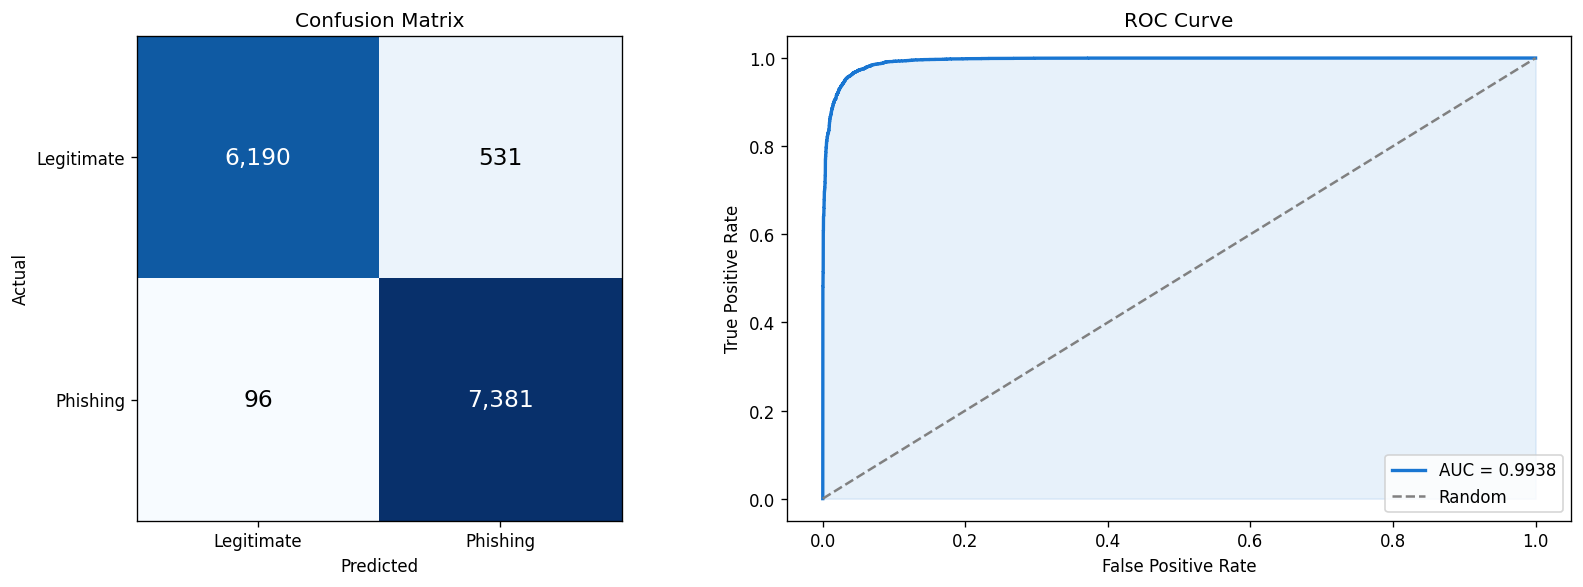

Evaluation plots saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix:
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Legitimate','Phishing'])
axes[0].set_yticklabels(['Legitimate','Phishing'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve:
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#1976D2', lw=2, label=f'AUC = {roc:.4f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('evaluation_plots.png', bbox_inches='tight')
plt.show()
print('Evaluation plots saved')

In [11]:
# Simple prediction threshold setup (default is balanced behavior):
prediction_threshold = 0.60

def set_prediction_threshold(value: float):
    """Update decision threshold for phishing classification."""
    global prediction_threshold
    prediction_threshold = float(np.clip(value, 0.0, 1.0))
    print(f'Prediction threshold set to: {prediction_threshold:.2f}')

print(f'Using default prediction threshold: {prediction_threshold:.2f}')
print("Call set_prediction_threshold(0.55) or similar to make the model less aggressive.")

Using default prediction threshold: 0.60
Call set_prediction_threshold(0.55) or similar to make the model less aggressive.


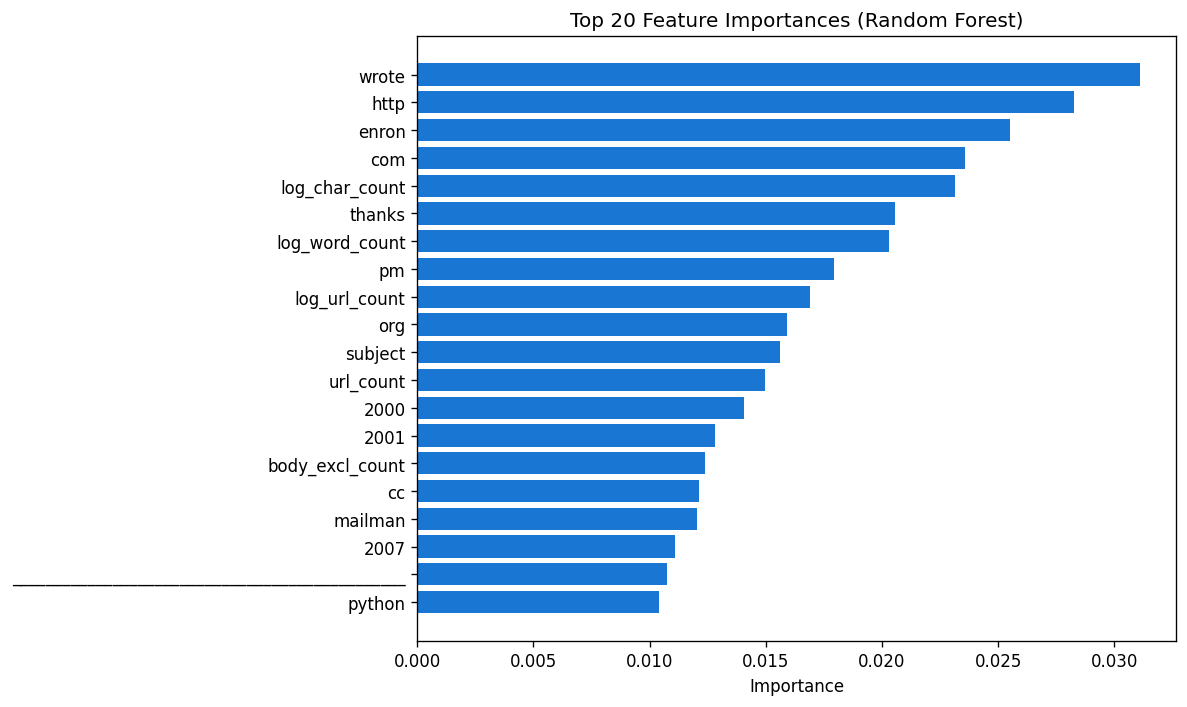

In [12]:
# Feature importance from Random Forest (top 20 numeric + text features):
rf_model = model_pipeline.named_steps['classifier'].estimators_[0]
preprocessor = model_pipeline.named_steps['features']

# Column Transformer exposes transformed feature names after fitting:
feat_names = preprocessor.get_feature_names_out().tolist()

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': rf_model.feature_importances_
})

# Optional cleanup to make labels easier to read in the chart:
importance_df['feature'] = (
    importance_df['feature']
    .str.replace('text__', '', regex=False)
    .str.replace('numeric__', '', regex=False)
)

importance_df = importance_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#1976D2')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 7\ Cross-Validation:

In [13]:
# Guard: confirm the pipeline was actually fitted before running CV
from sklearn.utils.validation import check_is_fitted
try:
    check_is_fitted(model_pipeline.named_steps['classifier'])
except Exception:
    raise RuntimeError(
        'model_pipeline is not fitted. Re-run the training cell before cross-validation.'
    )

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Cross-validation evaluates the exact same pipeline used for deployment
# n_jobs=-1 uses all CPU cores for faster CV:
cv_scores = cross_val_score(
    model_pipeline,
    X_train_raw,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    error_score='raise'
 )

print(f'3-Fold Cross-Validation ROC-AUC (FAST_MODE={FAST_MODE}):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

3-Fold Cross-Validation ROC-AUC (FAST_MODE=True):
  Fold 1: 0.9932
  Fold 2: 0.9931
  Fold 3: 0.9926
  Mean  : 0.9930 ± 0.0003


## 8\ Exporting the Model for Flask Deployment:

In [14]:
import joblib

joblib.dump(model_pipeline, 'phishing-api/phishing_model.pkl')
joblib.dump(prediction_threshold, 'phishing-api/threshold.pkl')
print('Model and threshold saved')

Model and threshold saved


## 9\ Inference Test:

In [15]:
def test_email(subject, body):
    """Run inference on one email using the trained end-to-end pipeline."""
    row = pd.DataFrame([{
        'subject': subject,
        'from_email': '',
        'to_email': '',
        'body_clean': body,
        'urls': '',
        'url_count': 0,
        'char_count': len(body),
        'word_count': len(body.split()),
        'has_ip_url': 0,
        'html_flag': 0,
    }])

    # Feature engineering is inside the pipeline, so pass raw fields directly
    prob = model_pipeline.predict_proba(row)[0][1]
    is_phishing = prob >= prediction_threshold
    prediction = 'phishing' if is_phishing else 'legitimate'

    print(f'Prediction : {prediction}')
    print(f'Probability: {prob:.4f}  (threshold={prediction_threshold:.2f})')

    return {
        'prediction': prediction,
        'is_phishing': bool(is_phishing),
        'probability': float(prob),
    }


print(' Test 1: Obvious phishing ')
test_email(
    subject='URGENT: Verify your account NOW or it will be suspended!',
    body='Click here to confirm your password immediately. Free prize winner! http://192.168.0.1/login',
)

print('\n Test 2: Obvious legitimate ')
test_email(
    subject='Meeting notes from Tuesday',
    body='Hi team, please find attached the notes from our Tuesday meeting. Best regards.',
)

print('\n Test 3: Threshold boundary : verify set_prediction_threshold works ')
result = test_email(
    subject='URGENT: Verify your account NOW or it will be suspended!',
    body='Click here to confirm your password immediately. Free prize winner! http://192.168.0.1/login',
)
# Temporarily raise threshold above this email's score to confirm it flips to 'legitimate'
_original = prediction_threshold
set_prediction_threshold(0.99)
result_high = test_email(
    subject='URGENT: Verify your account NOW or it will be suspended!',
    body='Click here to confirm your password immediately. Free prize winner! http://192.168.0.1/login',
)
assert result_high['prediction'] == 'legitimate', (
    f'Expected legitimate at threshold=0.99, got {result_high["prediction"]} '
    f'(prob={result_high["probability"]:.4f})'
)
set_prediction_threshold(_original)  # restore
print(f'\nThreshold boundary test passed  (restored threshold to {_original:.2f})')

 Test 1: Obvious phishing 
Prediction : phishing
Probability: 0.8474  (threshold=0.60)

 Test 2: Obvious legitimate 
Prediction : legitimate
Probability: 0.4834  (threshold=0.60)

 Test 3: Threshold boundary : verify set_prediction_threshold works 
Prediction : phishing
Probability: 0.8474  (threshold=0.60)
Prediction threshold set to: 0.99
Prediction : legitimate
Probability: 0.8474  (threshold=0.99)
Prediction threshold set to: 0.60

Threshold boundary test passed  (restored threshold to 0.60)
